## MSRA 命名实体识别（NER）任务

### 1.对MSRA数据做标签数量统计分析

Data Overview:
  text label
0    当     O
1    希     O
2    望     O
3    工     O
4    程     O

Value Counts in Second Column:
label
O        1928070
I-ORG      83585
I-LOC      49398
B-LOC      36517
I-PER      34123
B-ORG      20571
B-PER      17615
Name: count, dtype: int64

Value Details:
Value: O, Count: 1928070
Sample Data:
  text label
0    当     O
1    希     O
2    望     O
3    工     O
4    程     O
--------------------------------------------------
Value: I-ORG, Count: 83585
Sample Data:
     text  label
172     研  I-ORG
173     所  I-ORG
345     民  I-ORG
346     党  I-ORG
1082    军  I-ORG
--------------------------------------------------
Value: I-LOC, Count: 49398
Sample Data:
    text  label
115    京  I-LOC
143    京  I-LOC
166    宫  I-LOC
169    博  I-LOC
176    大  I-LOC
--------------------------------------------------
Value: B-LOC, Count: 36517
Sample Data:
    text  label
90     日  B-LOC
93     京  B-LOC
114    北  B-LOC
142    北  B-LOC
165    故  B-LOC
-------------------------

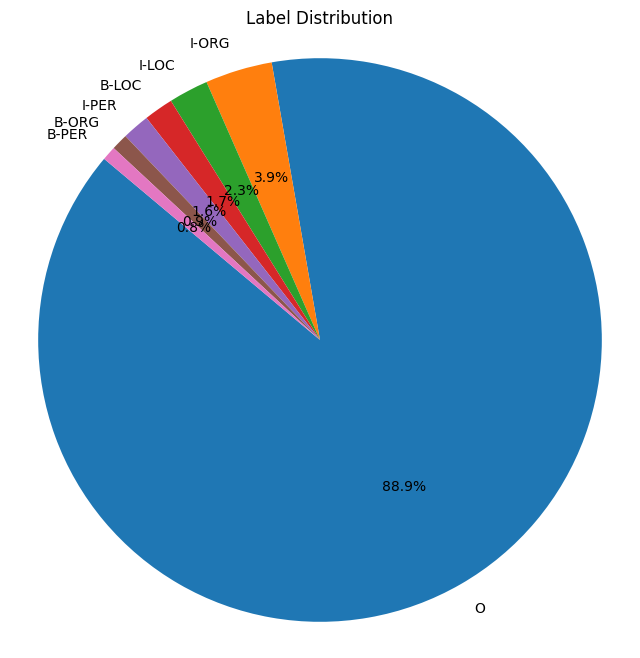

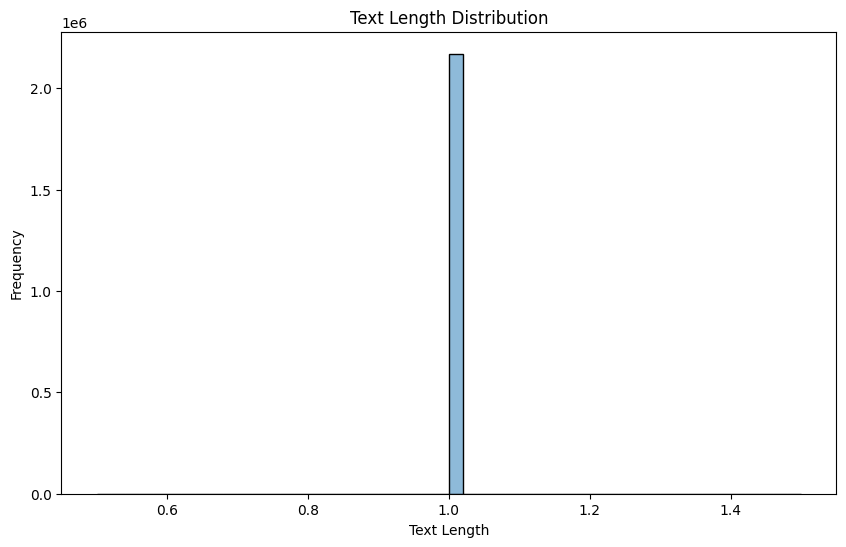


Summary:
Total number of unique texts: 7
Total number of rows: 2169879


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = './msra/train.txt' 
df = pd.read_csv(file_path, sep='\t', header=None, names=['text', 'label']) # 假设数据是用制表符分隔的

# 检查数据前几行
print("Data Overview:") 
print(df.head())

# 获取第二列标签列
second_column = df['label']

# 统计每个值的个数
value_counts = second_column.value_counts()

# 打印每个值的个数
print("\nValue Counts in Second Column:") 
print(value_counts)

# 打印每个值的具体内容
print("\nValue Details:")
for value, count in value_counts.items():
    print(f"Value: {value}, Count: {count}")
    # 打印该值的具体内容
    value_data = df[second_column == value] 
    print("Sample Data:") 
    print(value_data.head())
    print("-" * 50)
    
# 计算样本长度
df['text_length'] = df['text'].apply(len)

# 打印样本长度的基本统计信息
print("\nText Length Statistics:")
print(df['text_length'].describe())

# 类别分布
label_counts = df['label'].value_counts()
print("\nLabel Distribution:")
print(label_counts)

# 绘制类别分布饼图
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Label Distribution')
plt.axis('equal')
plt.show()

# 绘制样本长度分布图
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

# 输出总结
print("\nSummary:")
print(f"Total number of unique texts: {len(value_counts)}")
print(f"Total number of rows: {len(df)}")

### 2.对数据进行句子长度统计和词云图绘制

In [5]:
def obtain_sentence_labels(file_path):
    sentences, labels = [], []
    with open(file_path, 'r', encoding='utf-8') as file:
        sentence, label = [], []
        for line in file:
            # 如果是空行，表示一个句子结束
            if line.strip() == "":
                if sentence:
                    sentences.append(sentence)
                    labels.append(label)
                    sentence, label = [], []
            else:
                word, tag = line.strip().split()
                sentence.append(word)
                label.append(tag)
    return sentences, labels
file_path = "./msra/train.txt"
sentences, labels = obtain_sentence_labels(file_path)
len(sentences)

46364

In [6]:
# 输出部分句子
sentences[1]

['藏',
 '书',
 '本',
 '来',
 '就',
 '是',
 '所',
 '有',
 '传',
 '统',
 '收',
 '藏',
 '门',
 '类',
 '中',
 '的',
 '第',
 '一',
 '大',
 '户',
 '，',
 '只',
 '是',
 '我',
 '们',
 '结',
 '束',
 '温',
 '饱',
 '的',
 '时',
 '间',
 '太',
 '短',
 '而',
 '已',
 '。']

<>:48: SyntaxWarning: invalid escape sequence '\W'
<>:48: SyntaxWarning: invalid escape sequence '\W'
C:\Users\11415\AppData\Local\Temp\ipykernel_32976\112456824.py:48: SyntaxWarning: invalid escape sequence '\W'
  wordcloud = WordCloud(font_path='C:\Windows\Fonts\SimHei.ttf',width=800, height=400, background_color ='white').generate_from_frequencies(word_freq)


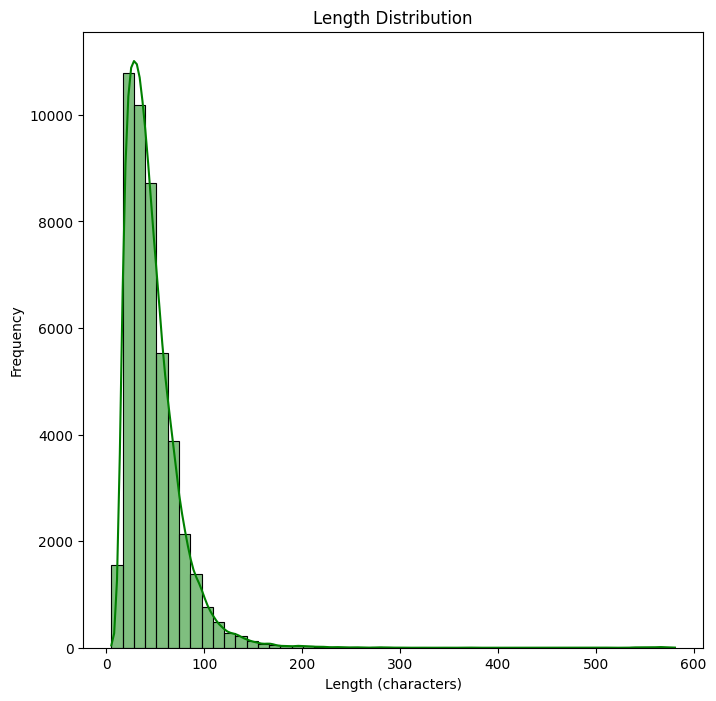

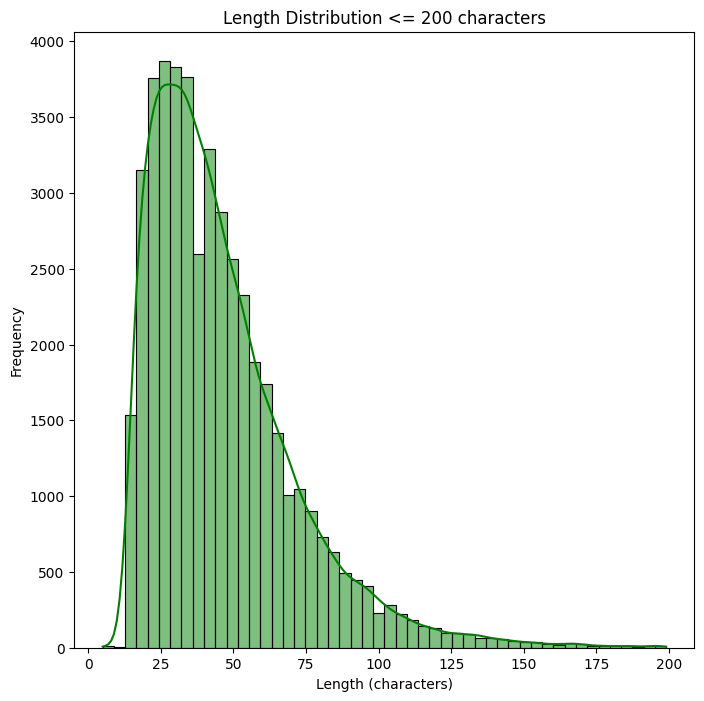

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\11415\AppData\Local\Temp\jieba.cache
Loading model cost 1.574 seconds.
Prefix dict has been built successfully.
C:\Users\11415\AppData\Local\Temp\ipykernel_32976\112456824.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.array(counts), y=np.array(words), palette='viridis')


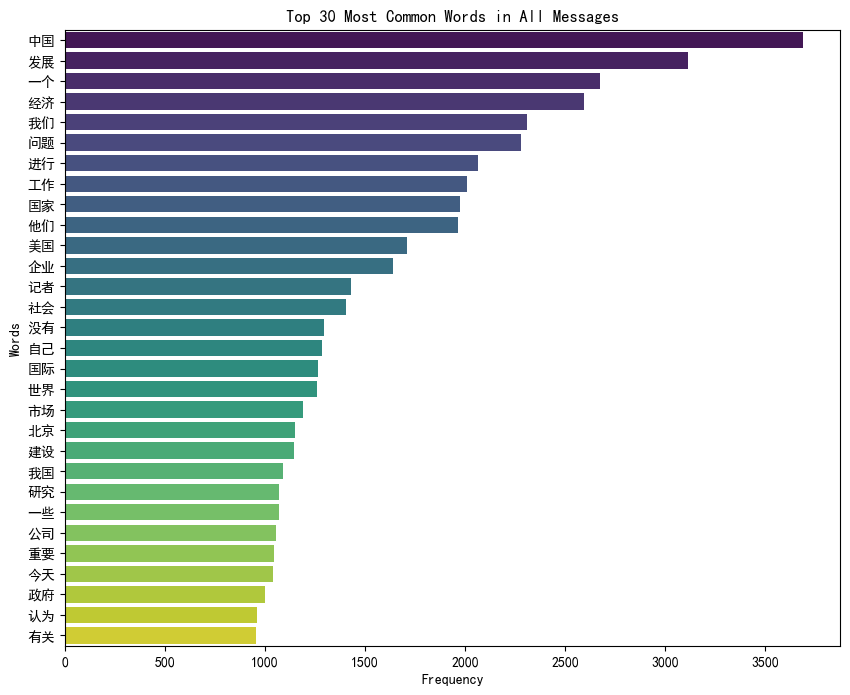

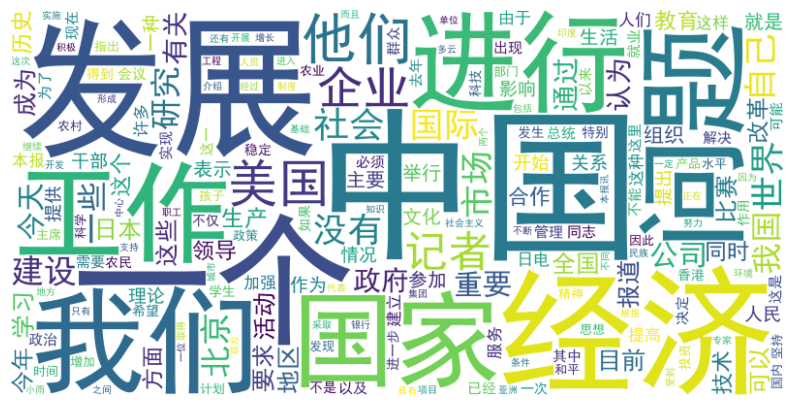

,O,B-LOC,I-LOC,B-ORG,I-ORG,B-PER,I-PER
count,46364.000000,46364.000000,46364.000000,46364.000000,46364.000000,46364.000000,46364.000000
mean,41.585497,0.787615,1.065439,0.443685,1.802800,0.379928,0.735981
std,26.985658,1.796591,2.622959,0.957343,4.423653,1.122278,2.358564
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,52.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000
max,482.000000,46.000000,56.000000,22.000000,177.000000,125.000000,248.000000


In [7]:
import seaborn as sns
sentence_lengths = [len(sentence) for sentence in sentences]
# 绘制文本长度的分布直方图
plt.figure(figsize=(8, 8))
sns.histplot(sentence_lengths, bins=50, kde=True, color='green')
plt.title('Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.show()

# 细致划分200词频以下的文本长度的分布直方图
sentence_lengths = [len(sentence) for sentence in sentences if len(sentence) < 200]
plt.figure(figsize=(8, 8))
sns.histplot(sentence_lengths, bins=50, kde=True, color='green')
plt.title('Length Distribution <= 200 characters')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.show()

## 画词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import jieba
from collections import Counter

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
all_text = "".join(["".join(sentence) for sentence in sentences])
words = jieba.cut(all_text)
most_common = Counter(words).most_common(400)
word_freq = {word: freq for word, freq in most_common if len(word) > 1}
word_freq

# 选择出现频率最高的单词-30个
n_words = 30
most_common_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:n_words]

# 绘制条形图展示最常见的单词
words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 8))
sns.barplot(x=np.array(counts), y=np.array(words), palette='viridis')
plt.title(f'Top {n_words} Most Common Words in All Messages')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

# 画词云图
wordcloud = WordCloud(font_path='C:\Windows\Fonts\SimHei.ttf',width=800, height=400, background_color ='white').generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

# 标签样本平均数量
import pandas as pd
tag_nums=[]
tags = ['O', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER']
for label in labels:
    tag_num={}
    for tag in tags:
        tag_num[tag]=label.count(tag)
    tag_nums.append(tag_num)
tag_df = pd.DataFrame(tag_nums)
tag_df.head()

tag_df.describe()

### 3.自定义模型--CRF模型和LSTM模型

#### 3.1 CRF模型

##### 载入数据

In [8]:
lxl_sentences_train, lxl_labels_train = obtain_sentence_labels("./msra/train.txt")
lxl_sentences_test, lxl_labels_test = obtain_sentence_labels("./msra/test.txt")

##### 特征提取

In [9]:
def word2features(sentence, i):
    word = sentence[i]
    features = {
        'bias': 1.0,  # 偏置项
        'word': word,  # 当前字符
        'is_first': i == 0,  # 是否是句子首字符
        'is_last': i == len(sentence) - 1,  # 是否是句子末字符
        'prev_word': '' if i == 0 else sentence[i - 1],  # 上一个字符
        'next_word': '' if i == len(sentence) - 1 else sentence[i + 1],  # 下一个字符
    }
    return features

def sentence2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

# 特征示例
print(sentence2features(['比', '如', '三', '资', '企', '业', '运', '动', '会']))

[{'bias': 1.0, 'word': '比', 'is_first': True, 'is_last': False, 'prev_word': '', 'next_word': '如'}, {'bias': 1.0, 'word': '如', 'is_first': False, 'is_last': False, 'prev_word': '比', 'next_word': '三'}, {'bias': 1.0, 'word': '三', 'is_first': False, 'is_last': False, 'prev_word': '如', 'next_word': '资'}, {'bias': 1.0, 'word': '资', 'is_first': False, 'is_last': False, 'prev_word': '三', 'next_word': '企'}, {'bias': 1.0, 'word': '企', 'is_first': False, 'is_last': False, 'prev_word': '资', 'next_word': '业'}, {'bias': 1.0, 'word': '业', 'is_first': False, 'is_last': False, 'prev_word': '企', 'next_word': '运'}, {'bias': 1.0, 'word': '运', 'is_first': False, 'is_last': False, 'prev_word': '业', 'next_word': '动'}, {'bias': 1.0, 'word': '动', 'is_first': False, 'is_last': False, 'prev_word': '运', 'next_word': '会'}, {'bias': 1.0, 'word': '会', 'is_first': False, 'is_last': True, 'prev_word': '动', 'next_word': ''}]


In [10]:
# 使用ACC Precision,Recall和F1进行多分类
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate(y_true, y_pred):
    p = precision_score(y_true, y_pred, average='macro')
    r = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Precision: {p}, Recall: {r}, F1: {f1}")
    return  p, r, f1

In [9]:
# 模型训练评估
from sklearn_crfsuite import CRF
from sklearn_crfsuite.metrics import flat_classification_report
X_train = [sentence2features(s) for s in lxl_sentences_train]
y_train = lxl_labels_train
X_test = [sentence2features(s) for s in lxl_sentences_test]
y_test = lxl_labels_test
# 定义并训练CRF模型
crf = CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100,  all_possible_transitions=True)
crf.fit(X_train, y_train)
# 预测和评估
y_pred = crf.predict(X_test)
print(flat_classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       B-LOC       0.90      0.82      0.86      2877
       B-ORG       0.78      0.71      0.74      1331
       B-PER       0.93      0.73      0.82      1973
       I-LOC       0.87      0.73      0.79      4394
       I-ORG       0.79      0.76      0.78      5670
       I-PER       0.86      0.88      0.87      3851
           O       0.98      0.99      0.99    152505

    accuracy                           0.97    172601
   macro avg       0.87      0.80      0.83    172601
weighted avg       0.96      0.97      0.96    172601



#### 3.2 使用LSTM模型进行训练并在测试集上预测，评估指标使用 Precision,Recall,F1。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter

def load_msra_data():
    texts = []
    labels = []
    with open('./msra/test.txt', 'r', encoding='utf-8') as file:
        for row in file.readlines():
            try:
                text, label = row.strip().split('\t')
                texts.append(text)
                labels.append(label)
            except:
                pass
    return texts, labels

def clean_text(text):
    return ''.join([c.lower() for c in text if c.isalnum() or c == ' '])

def build_vocab(texts, max_vocab_size=1000):
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    vocab = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:max_vocab_size]
    word2idx = {word: idx + 1 for idx, (word, _) in enumerate(vocab)}
    return word2idx

def text_to_sequence(text, word2idx, max_len=20):
    sequence = [word2idx.get(word, 0) for word in text.split()]
    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

class MSRADataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model, test_loader, device):
    model.eval()
    true_labels = []
    predicted_labels = []
    
    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')
    f1 = f1_score(true_labels, predicted_labels, average='weighted')
    
    return accuracy, precision, recall, f1

def main():
    texts, labels = load_msra_data()
    texts = [clean_text(text) for text in texts]
    word2idx = build_vocab(texts)
    sequences = [text_to_sequence(text, word2idx) for text in texts]
    
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    X_train, X_test, y_train, y_test = train_test_split(sequences, labels, test_size=0.2, random_state=42)
    
    train_dataset = MSRADataset(X_train, y_train)
    test_dataset = MSRADataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    vocab_size = len(word2idx) + 1
    embed_size = 128
    hidden_size = 128
    num_classes = len(set(labels))
    
    model = LSTMModel(vocab_size, embed_size, hidden_size, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    
    num_epochs = 5
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, criterion, optimizer, device)
        accuracy, precision, recall, f1 = evaluate(model, test_loader, device)
        metric_str = f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}"
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f},  {metric_str}')

if __name__ == '__main__':
    main()

D:\Anaconda\envs\nlp_learning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [1/5], Loss: 0.5612,  Accuracy: 0.8840, Precision: 0.7814, Recall: 0.8840, F1-Score: 0.8295


D:\Anaconda\envs\nlp_learning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [2/5], Loss: 0.5588,  Accuracy: 0.8840, Precision: 0.7814, Recall: 0.8840, F1-Score: 0.8295


D:\Anaconda\envs\nlp_learning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [3/5], Loss: 0.5588,  Accuracy: 0.8840, Precision: 0.7814, Recall: 0.8840, F1-Score: 0.8295


D:\Anaconda\envs\nlp_learning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [4/5], Loss: 0.5588,  Accuracy: 0.8840, Precision: 0.7814, Recall: 0.8840, F1-Score: 0.8295
Epoch [5/5], Loss: 0.5588,  Accuracy: 0.8840, Precision: 0.7814, Recall: 0.8840, F1-Score: 0.8295


D:\Anaconda\envs\nlp_learning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3.基于大模型接口，设计NER任务的Prompt，在测试集上对大模型的效果做评估

In [37]:
## 定义 api_key
import re
from openai import OpenAI
import os
import json
api_key = "sk-57aba60ba5b44aedab3380a7fc2322b1"
sentences, labels = obtain_sentence_labels("./msra/test.txt")

In [38]:
def get_response(messages,api_key):
    client = OpenAI(
        # 如果您没有配置环境变量，请在此处用您的API Key进行替换
        api_key= api_key,
        # 填写DashScope服务的base_url
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    )
    completion = client.chat.completions.create(
        model="qwen-plus",
        messages=messages
        )
    return completion

In [39]:
from sklearn.metrics import  precision_score, recall_score, f1_score
def evaluate_ai(y_true, y_pred):
    p = precision_score(y_true, y_pred, average='macro')
    r = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Precision: {p:.4f}, Recall: {r:.4f}, F1: {f1:.4f}")
    return f"{p:.4f},{r:.4f},{f1:.4f}"

In [40]:
def record_log(index,result,status):
    message = f"{index}\t{result}\t{status}"
    with open("Blog.txt", "a") as f:
        f.write(message+"\n")
def read_log():
    with open("Blog.txt", "r") as f:
        lines =f.readlines()
        if len(lines) == 0:
            return "0", "0", "0"
        last_line = lines[-1]
        index, result, status = last_line.strip().split("\t")
    return index.strip(), result, status
read_log()

('0', '0', '0')

In [41]:
messages =[
         {'role': 'system', 
          'content': '''对于以下文本，请逐字进行命名实体识别，并标注每个字的命名实体类别。左侧是字符，右侧是标签，以 \t 分割。标签规则如下：
- B-ORG 和 I-ORG：表示组织名的开头和中间。
- B-PER 和 I-PER：表示人名的开头和中间。
- B-LOC 和 I-LOC：表示地名的开头和中间。
- O：表示其他非实体词。

文本示例：张三在北京大学工作。
期望输出：
张    B-PER
三    I-PER
在    O
北    B-LOC
京    I-LOC
大    B-ORG
学    I-ORG
工    I-ORG
作    O
'''}
]

In [47]:
# 您可以自定义设置对话轮数
for idx in range(2):
    print(f"第{idx+1}轮对话",end="\t")
    sentence = "".join(sentences[idx])
    # 将用户问题信息添加到messages列表中
    messages.append({'role': 'user', 'content':"文本:"+sentence})
    try:
        completion = get_response(messages,api_key)
        res_json = json.loads(completion.to_json())
        print("token-{}".format(res_json["usage"]["total_tokens"]),end="\t")
        labels_predict = [re.split(r"\s+",label)[1] for label in res_json["choices"][0]["message"]["content"].split("\n") if label != "" ]
        result = evaluate_ai(labels_predict, labels[idx])
    except Exception as e:     
        print(e)
# 删除最后一条消息
    messages.pop()

第1轮对话	token-261	Found input variables with inconsistent numbers of samples: [14, 16]
第2轮对话	token-219	Precision: 1.0000, Recall: 1.0000, F1: 1.0000


In [43]:
import warnings
warnings.filterwarnings("ignore")

In [48]:
# 您可以自定义设置对话轮数
def write_result(pridict_result, labels_true):
    with open("result.txt", "a+") as f:
        for index ,item  in enumerate(zip(pridict_result, labels_true)):
            predict, true = item
            f.write(f"{predict}\t{true}\n")
            
def read_result():
    df = pd.read_csv("result.txt", sep="\t", names=["predict", "true"])
    return df
        
start_index = int(read_log()[0].strip())
start_index

0

In [49]:
start_index = int(read_log()[0].strip())
for idx in range(start_index,start_index+5):
    print(f"第{idx+1}句",end="\t")
    sentence = "".join(sentences[idx])
    # 将用户问题信息添加到messages列表中
    messages.append({'role': 'user', 'content':"文本:"+sentence})
    try:
        completion = get_response(messages,api_key)
        res_json = json.loads(completion.to_json())
        labels_predict = [re.split(r"\s+",label)[1] for label in res_json["choices"][0]["message"]["content"].split("\n") if label != "" ]
        print("消耗token-{}".format(res_json["usage"]["total_tokens"]),end="\t")
        result = evaluate_ai(labels_predict, labels[idx])
        write_result(labels_predict, labels[idx])
        record_log(idx, result, "success")
    except Exception as e:     
        record_log(idx, "fail", "fail")
        print(e)
# 删除最后一条消息
    messages.pop()

第1句	消耗token-271	Precision: 1.0000, Recall: 1.0000, F1: 1.0000
第2句	消耗token-219	Precision: 1.0000, Recall: 1.0000, F1: 1.0000
第3句	消耗token-450	Precision: 0.4373, Recall: 0.4762, F1: 0.4368
第4句	消耗token-211	Precision: 1.0000, Recall: 1.0000, F1: 1.0000
第5句	消耗token-506	Precision: 0.9333, Recall: 0.9933, F1: 0.9566


In [50]:
result_df = read_result()
result_df.head()

,predict,true
0,B-ORG,B-ORG
1,I-ORG,I-ORG
2,I-ORG,I-ORG
3,I-ORG,I-ORG
4,O,O


In [51]:
from sklearn.metrics import classification_report
print(classification_report(result_df["predict"], result_df["true"]))

              precision    recall  f1-score   support

       B-LOC       0.00      0.00      0.00         1
       B-ORG       0.86      0.86      0.86         7
       B-PER       1.00      1.00      1.00         1
       I-LOC       0.00      0.00      0.00         1
       I-ORG       0.66      1.00      0.79        27
       I-PER       1.00      1.00      1.00         2
           O       1.00      0.90      0.95       117

    accuracy                           0.90       156
   macro avg       0.65      0.68      0.66       156
weighted avg       0.92      0.90      0.90       156



In [52]:
### 总共1百万token 一句话500，大概2000句话，保险起见，设置1000句话
start_index = int(read_log()[0].strip())
for idx in range(start_index,1000):
    print(f"第{idx+1}句",end="\t")
    sentence = "".join(sentences[idx])
    # 将用户问题信息添加到messages列表中
    messages.append({'role': 'user', 'content':"文本:"+sentence})
    try:
        completion = get_response(messages,api_key)
        res_json = json.loads(completion.to_json())
        labels_predict = [re.split(r"\s+",label)[1] for label in res_json["choices"][0]["message"]["content"].split("\n") if label != "" ]
        print("消耗token-{}".format(res_json["usage"]["total_tokens"]),end="\t")
        result = evaluate_ai(labels_predict, labels[idx])
        write_result(labels_predict, labels[idx])
        record_log(idx, result, "success")
    except Exception as e:     
        record_log(idx, "fail", "fail")
        print(e)
# 删除最后一条消息
    messages.pop()

第5句	消耗token-506	Precision: 0.9333, Recall: 0.9933, F1: 0.9566
第6句	消耗token-468	Precision: 0.9889, Recall: 0.6667, F1: 0.7721
第7句	消耗token-655	Precision: 0.3270, Recall: 0.3333, F1: 0.3302
第8句	消耗token-516	Found input variables with inconsistent numbers of samples: [66, 65]
第9句	消耗token-579	Precision: 0.3023, Recall: 0.3333, F1: 0.3171
第10句	消耗token-423	Precision: 0.2956, Recall: 0.3333, F1: 0.3133
第11句	消耗token-327	Found input variables with inconsistent numbers of samples: [29, 28]
第12句	消耗token-311	Precision: 0.6026, Recall: 0.8551, F1: 0.6198
第13句	消耗token-369	Found input variables with inconsistent numbers of samples: [42, 40]
第14句	消耗token-701	Precision: 0.8438, Recall: 0.8453, F1: 0.7861
第15句	消耗token-548	Precision: 0.7372, Recall: 0.5000, F1: 0.5768
第16句	Error code: 400 - {'error': {'code': 'data_inspection_failed', 'param': None, 'message': 'Input data may contain inappropriate content.', 'type': 'data_inspection_failed'}, 'id': 'chatcmpl-4d9c7dc9-4198-90b1-b805-43a6ad8bea44', 'request_i

In [53]:
result_df = read_result()
print(classification_report(result_df["predict"], result_df["true"]))

              precision    recall  f1-score   support

      B-DATE       0.00      0.00      0.00         1
       B-LOC       0.88      0.72      0.80      1141
      B-MISC       0.00      0.00      0.00         1
       B-ORG       0.77      0.49      0.60       606
       B-PER       0.99      0.95      0.97       417
       B-TIM       0.00      0.00      0.00         3
      B-TIME       0.00      0.00      0.00         2
      I-DATE       0.00      0.00      0.00         8
       I-LOC       0.84      0.65      0.74      1758
      I-MISC       0.00      0.00      0.00         3
       I-ORG       0.77      0.59      0.67      2202
       I-PER       0.99      0.86      0.92       877
       I-TIM       0.00      0.00      0.00         7
      I-TIME       0.00      0.00      0.00         4
           O       0.95      0.99      0.97     33356

    accuracy                           0.93     40386
   macro avg       0.41      0.35      0.38     40386
weighted avg       0.93   

In [54]:
## 删除不对的tag,使得AI模型进一步优化问题解决
result_df["predict"][result_df["predict"].isin(tags)]

0        B-ORG
1        I-ORG
2        I-ORG
3        I-ORG
4            O
         ...  
40381        O
40382        O
40383        O
40384        O
40385        O
Name: predict, Length: 40357, dtype: object

In [55]:
print(classification_report(result_df["predict"][result_df["predict"].isin(tags)], result_df["true"][result_df["predict"].isin(tags)]))

              precision    recall  f1-score   support

       B-LOC       0.88      0.72      0.80      1141
       B-ORG       0.77      0.49      0.60       606
       B-PER       0.99      0.95      0.97       417
       I-LOC       0.84      0.65      0.74      1758
       I-ORG       0.77      0.59      0.67      2202
       I-PER       0.99      0.86      0.92       877
           O       0.95      0.99      0.97     33356

    accuracy                           0.93     40357
   macro avg       0.89      0.75      0.81     40357
weighted avg       0.93      0.93      0.93     40357

